<a href="https://colab.research.google.com/github/Turbonik/AILab1/blob/main/Lab1AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Введение
## Цель работы:
изучение основ линейной регрессии, построение простейших моделей регрессии, проведение обучения модели на реальных данных и оценка её качество.
## Задачи:
1. Провести обучение модели линейной регрессии на датасете с Kaggle:
2. Загрузить датасет из репозитория (например, kaggle.com или аналогичных платформ).
3. Подготовить данные: провести первичный анализ, визуализировать распределение признаков и целевой переменной.
4. Провести предобработку данных: удалить пропущенные значения, закодировать категориальные переменные (опционально).
5. Построить матрицу корреляций. Сделать выводы о наличии мультиколлинеарности (расчет VIF-коэффициента).
6. Построить регрессионные модели (линейная, лассо и гребневая). Если целевая переменная - категориальная, то исследовать логистическую регрессию. Разделить на тренировочную и тестовую выборки (80/20 или 70/30). Использовать кросс-валидацию. Оценить качество построенной модели с помощью метрик: RMSE (Root Mean Square Error), R² (коэффициент детерминации) и MAPE (Mean Absolute Percentage Error).
7. Устранить мультиколлинеарность и снизить размерность признаков с помощью метода главных компонент (PCA). Перед проведением PCA провести стандартизацию данных.
8. Повторить шаг 5 (линейная, лассо и гребневая регрессия), но использовать в качестве признаков не исходные данные, а главные компоненты. Сравнить метрики качества (RMSE, R² и MAPE) моделей, обученных на исходных данных и на главных компонентах.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold, cross_validate
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

!wget -O Housing.csv https://raw.githubusercontent.com/Turbonik/AILab1/main/Housing.csv


--2026-09-17 15:12:19--  https://raw.githubusercontent.com/Turbonik/AILab1/main/Housing.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 29981 (29K) [text/plain]
Saving to: ‘Housing.csv’

Housing.csv         100%[===================>]  29.28K  --.-KB/s    in 0s      

2026-09-17 15:12:20 (99.7 MB/s) - ‘Housing.csv’ saved [29981/29981]



## Описание датасета

В работе используется датасет Housing.csv, содержащий информацию об объектах недвижимости.
Всего 545 строк и 13 признаков. Целевая переменная — price.
Признаки включают числовые (area, bedrooms, bathrooms, stories, parking) и категориальные (mainroad, guestroom, basement, hotwaterheating, airconditioning, prefarea, furnishingstatus).


Статистика по числовым признакам:
              price          area    bedrooms   bathrooms     stories  \
count  5.450000e+02    545.000000  545.000000  545.000000  545.000000   
mean   4.766729e+06   5150.541284    2.965138    1.286239    1.805505   
std    1.870440e+06   2170.141023    0.738064    0.502470    0.867492   
min    1.750000e+06   1650.000000    1.000000    1.000000    1.000000   
25%    3.430000e+06   3600.000000    2.000000    1.000000    1.000000   
50%    4.340000e+06   4600.000000    3.000000    1.000000    2.000000   
75%    5.740000e+06   6360.000000    3.000000    2.000000    2.000000   
max    1.330000e+07  16200.000000    6.000000    4.000000    4.000000   

          parking  
count  545.000000  
mean     0.693578  
std      0.861586  
min      0.000000  
25%      0.000000  
50%      0.000000  
75%      1.000000  
max      3.000000  

Медианы числовых признаков:
price        4340000.0
area            4600.0
bedrooms           3.0
bathrooms          1.0
storie

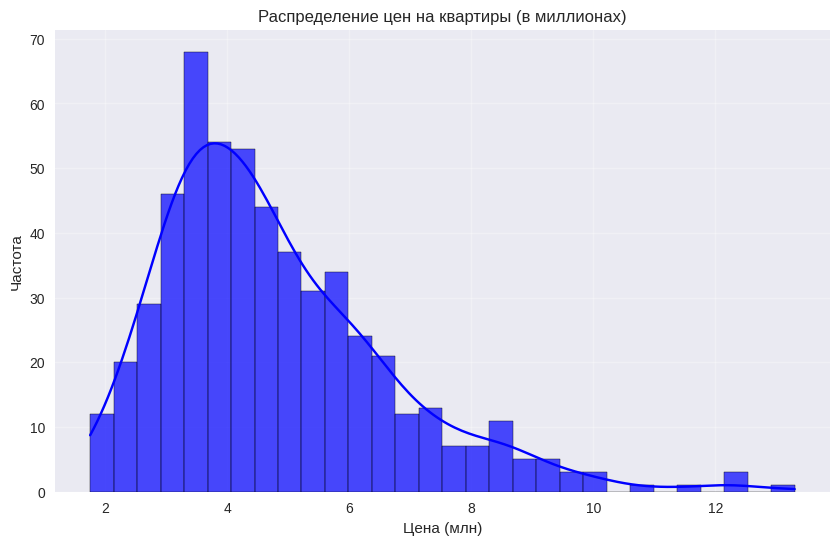

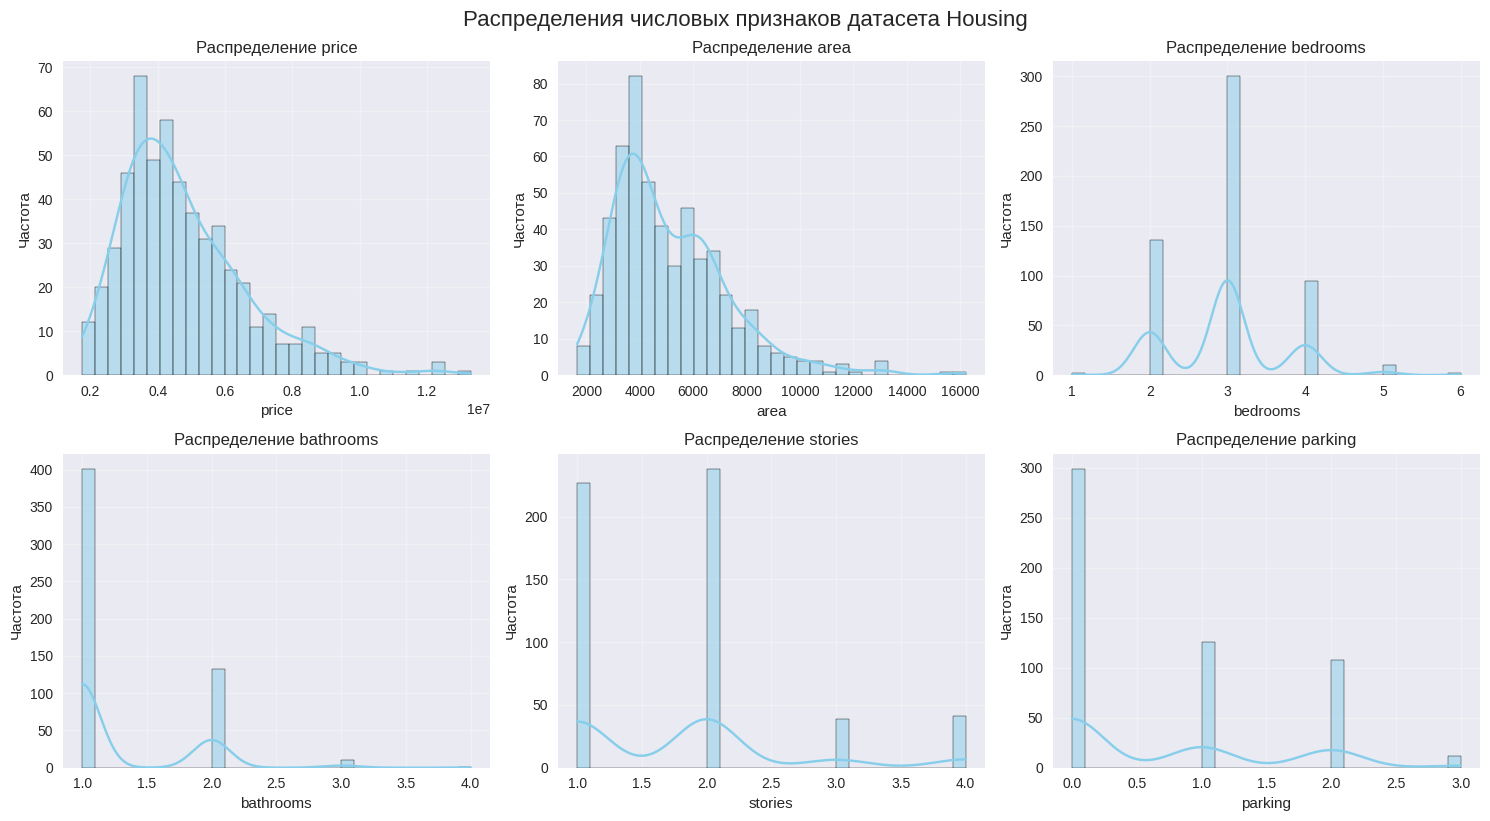

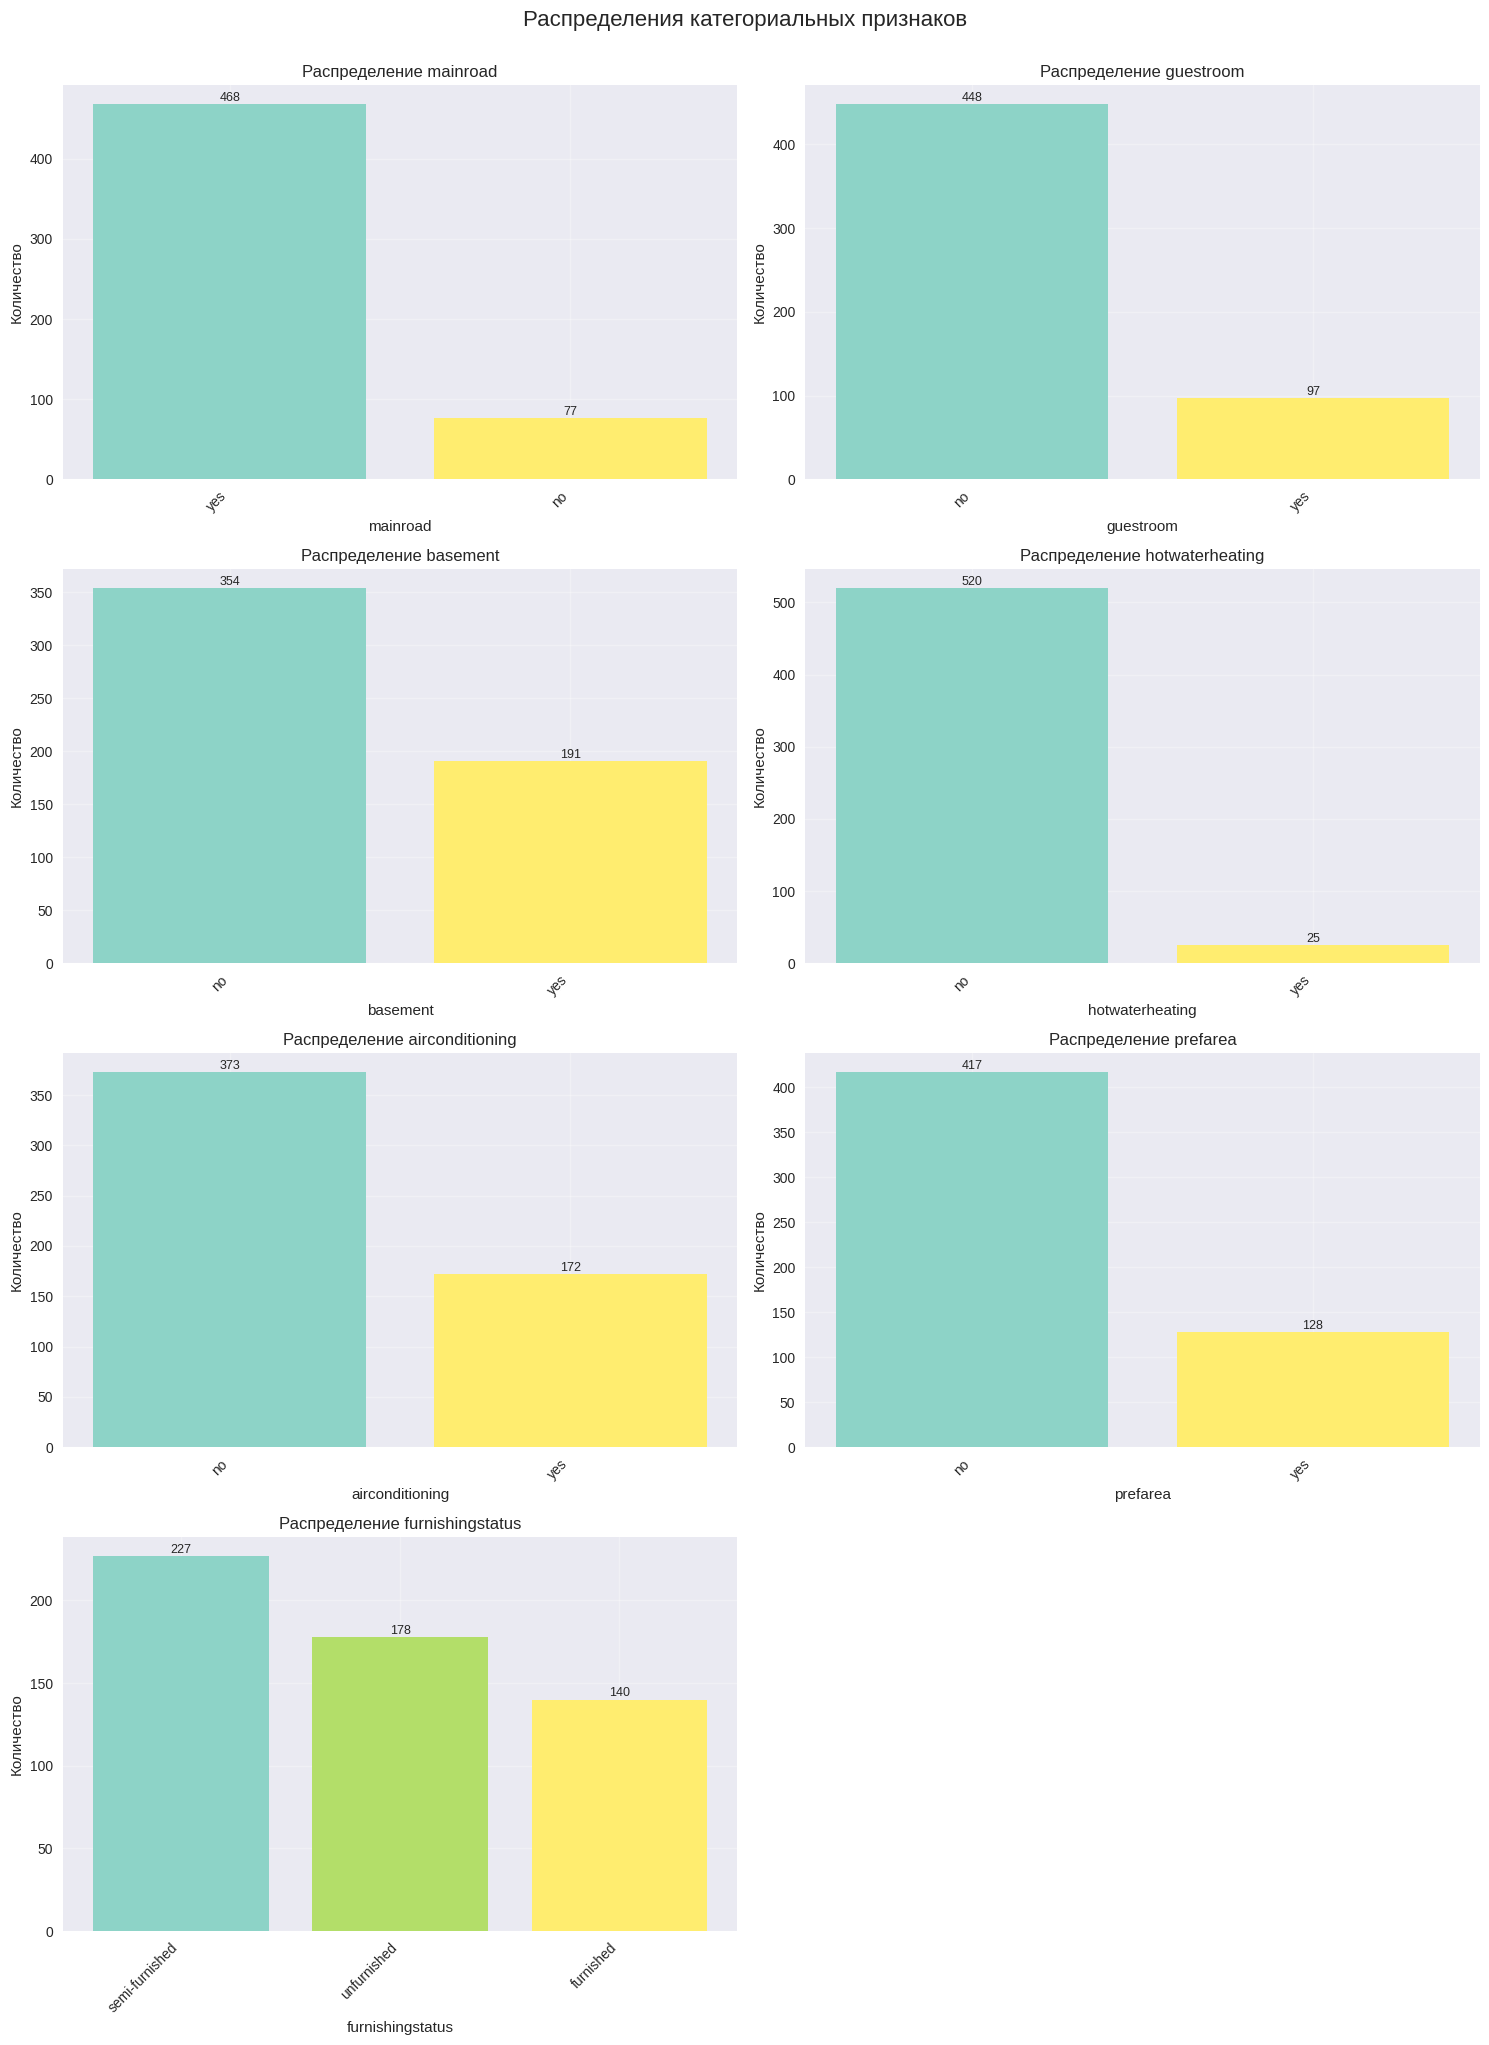


Статистика по цене (price)

Среднее: 4766729.25
Медиана: 4340000.00
Стандартное отклонение: 1870439.62
Минимум: 1750000.00
Максимум: 13300000.00
25-й перцентиль: 3430000.00
75-й перцентиль: 5740000.00
Квартильный размах: 2310000.00


In [2]:
data = pd.read_csv('Housing.csv')
print("\nСтатистика по числовым признакам:")
print(data.describe())

numeric_columns = data.select_dtypes(include=[np.number]).columns
categorical_columns = data.select_dtypes(include=['object']).columns

print("\nМедианы числовых признаков:")
print(data[numeric_columns].median())

print("\nСтандартные отклонения числовых признаков:")
print(data[numeric_columns].std())

print("\nМоды категориальных признаков:")
for col in categorical_columns:
    mode_values = data[col].mode()
    if not mode_values.empty:
        print(f"{col}: {mode_values.iloc[0]}")
    else:
        print(f"{col}: No mode")

plt.figure(figsize=(10, 6))
sns.histplot(data["price"] / 1_000_000, bins=30, kde=True, color="blue", alpha=0.7)
plt.title("Распределение цен на квартиры (в миллионах)")
plt.xlabel("Цена (млн)")
plt.ylabel("Частота")
plt.grid(True, alpha=0.3)
plt.show()


numeric_data = data[numeric_columns]

n_cols = 3
n_rows = (len(numeric_data.columns) + n_cols - 1) // n_cols

plt.figure(figsize=(15, n_rows * 4))
for i, column in enumerate(numeric_data.columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(data[column], bins=30, kde=True, color="skyblue", edgecolor="black")
    plt.title(f"Распределение {column}")
    plt.xlabel(column)
    plt.ylabel("Частота")
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle("Распределения числовых признаков датасета Housing", fontsize=16, y=1.02)
plt.show()

categorical_data = data[categorical_columns]

reasonable_categorical = [col for col in categorical_data.columns
                          if data[col].nunique() <= 20]

if reasonable_categorical:
    n_cols_cat = 2
    n_rows_cat = (len(reasonable_categorical) + n_cols_cat - 1) // n_cols_cat

    plt.figure(figsize=(15, n_rows_cat * 5))
    for i, column in enumerate(reasonable_categorical, 1):
        plt.subplot(n_rows_cat, n_cols_cat, i)

        value_counts = data[column].value_counts().head(15)

        if len(value_counts) > 0:
            bars = plt.bar(range(len(value_counts)), value_counts.values,
                           color=plt.cm.Set3(np.linspace(0, 1, len(value_counts))))
            plt.title(f"Распределение {column}")
            plt.xlabel(column)
            plt.ylabel("Количество")
            plt.xticks(range(len(value_counts)), value_counts.index, rotation=45, ha='right')
            plt.grid(True, alpha=0.3)

            for bar, count in zip(bars, value_counts.values):
                plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                         str(count), ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.suptitle("Распределения категориальных признаков", fontsize=16, y=1.02)
    plt.show()

print("\nСтатистика по цене (price)\n")
price_stats = {
    'Среднее': data['price'].mean(),
    'Медиана': data['price'].median(),
    'Стандартное отклонение': data['price'].std(),
    'Минимум': data['price'].min(),
    'Максимум': data['price'].max(),
    '25-й перцентиль': data['price'].quantile(0.25),
    '75-й перцентиль': data['price'].quantile(0.75),
    'Квартильный размах': data['price'].quantile(0.75) - data['price'].quantile(0.25)
}

for stat, value in price_stats.items():
    print(f"{stat}: {value:.2f}")


## Выводы по целевой переменной (price)
Распределение цен правостороннее асимметричное (среднее (**4.77 млн**) больше медианы (**4.34 млн**)).
То есть, большинство квартир дешевле, чем кажется по среднему.

Стандартное отклонение = 1.87 млн очень большое. то есть цены в среднем варьируются в диапазоне **4.77 млн +- 1.87 млн**.
квартильный размах задает диапазон **от 3.43 млн до 5.74 млн** между 25-ым и 75-ым процентилем. Большинство квартир относится к этому сегменту.  

Есть выбросы.  
Максимальная цена = 13.3 млн — это сильно выше типичного диапазона.
Такие объекты могут влиять на модель.

Минимальная цена = 1.75 млн.  

In [3]:
binary_cols = ["mainroad", "guestroom", "basement",
               "hotwaterheating", "airconditioning", "prefarea"]


for col in binary_cols:
    if data[col].dtype == "object":
        data[col] = data[col].str.lower().map({"yes": 1, "no": 0})


X = data.drop(["price", "furnishingstatus"], axis=1)

y = data["price"]

print(data.isna().sum())

scaler = StandardScaler()
num_cols = X.select_dtypes(include=[np.number]).columns
X[num_cols] = scaler.fit_transform(X[num_cols])

X.head()



price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea
0,1.046726,1.403419,1.421812,1.378217,0.405623,-0.465315,-0.734539,-0.219265,1.472618,1.517692,1.804941
1,1.757010,1.403419,5.405809,2.532024,0.405623,-0.465315,-0.734539,-0.219265,1.472618,2.679409,-0.554035
2,2.218232,0.047278,1.421812,0.224410,0.405623,-0.465315,1.361397,-0.219265,-0.679063,1.517692,1.804941
3,1.083624,1.403419,1.421812,0.224410,0.405623,-0.465315,1.361397,-0.219265,1.472618,2.679409,1.804941
4,1.046726,1.403419,-0.570187,0.224410,0.405623,2.149083,1.361397,-0.219265,1.472618,1.517692,-0.554035


# Предобработка данных
### **1. Проверка и обработка пропусков:**
В датасете отсутствуют пропуски во всех признаках (545 наблюдений в каждом столбце). Дополнительная обработка пропусков не требуется.
### **2. Кодирование категориальных признаков**
Бинарные признаки (mainroad, guestroom, basement, hotwaterheating, airconditioning, prefarea) преобразованы в формат 1/0.
Признак furnishingstatus исключен.

Для подготовки данных к моделированию были выделены числовые признаки и выполнена их стандартизация с использованием StandardScaler. Это привело все признаки к единому масштабу (среднее = 0, стандартное отклонение = 1).
После нормализации данные были разделены на обучающую и тестовую выборки в пропорции 80/20 с фиксированным параметром random_state=42 для воспроизводимости результатов.

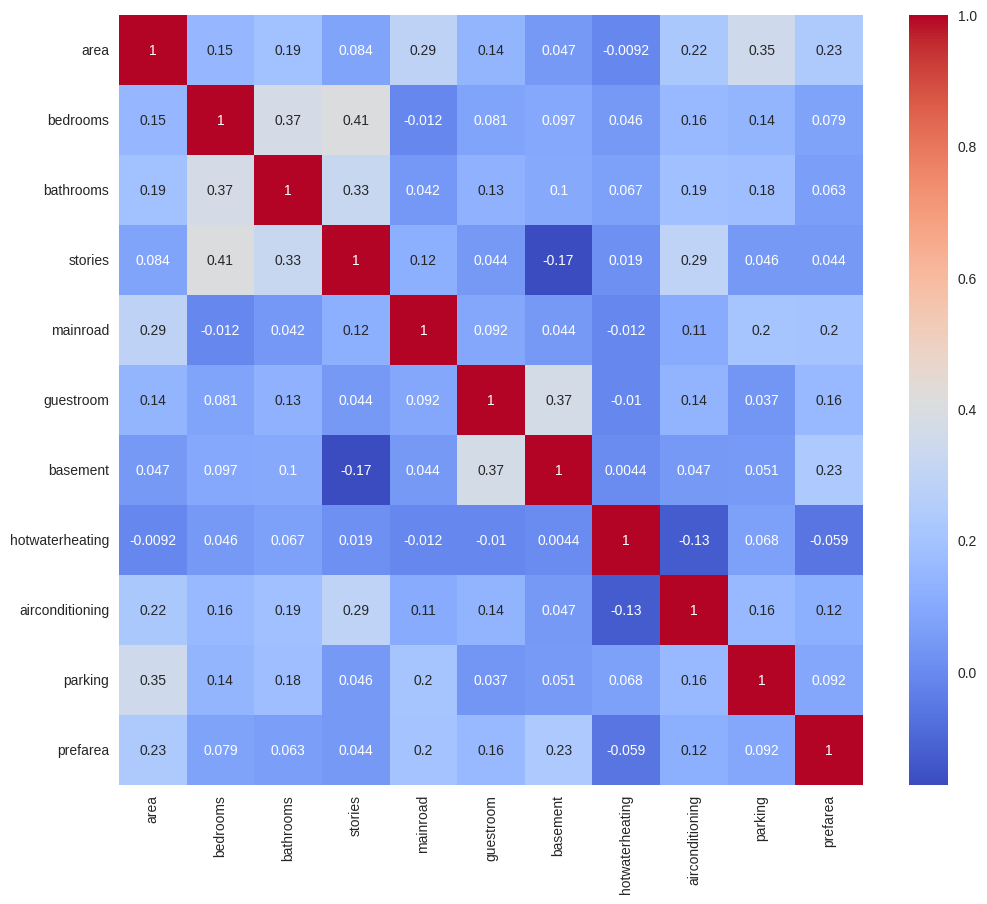

,feature,VIF
0,area,1.321650
1,bedrooms,1.365665
2,bathrooms,1.283520
3,stories,1.476607
4,mainroad,1.163132
5,guestroom,1.210425
6,basement,1.315268
7,hotwaterheating,1.038161
8,airconditioning,1.200862
9,parking,1.201129


In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor

corr = X.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data


# Матрица корреляций и VIF
Матрица корреляций показывает отсутствие сильных линейных связей между признаками. Максимальная корреляция составляет около 0.41, что является слабой зависимостью.

Расчёт VIF подтверждает отсутствие мультиколлинеарности: все коэффициенты находятся в диапазоне 1.03–1.47.

Таким образом, матрица признаков хорошо обусловлена, линейная регрессия будет устойчива, а коэффициенты — интерпретируемы.

Линейная регрессия
            Признак    Коэффициент
0              area  515391.840481
1          bedrooms   57872.776436
2         bathrooms  556891.067242
3           stories  370000.899864
4          mainroad  143741.723580
5         guestroom   93178.807282
6          basement  207547.046639
7   hotwaterheating  149010.395051
8   airconditioning  375713.439539
9           parking  212997.799147
10         prefarea  269942.441625
Ridge регрессия

             Признак    Коэффициент
0              area  514429.304696
1          bedrooms   58804.618019
2         bathrooms  555669.478204
3           stories  369156.803771
4          mainroad  143970.150589
5         guestroom   93553.490675
6          basement  206944.998735
7   hotwaterheating  148681.605072
8   airconditioning  375329.796184
9           parking  213077.509621
10         prefarea  269485.952075
Lasso регрессия

             Признак    Коэффициент
0              area  515391.543262
1          bedrooms   57872.611701


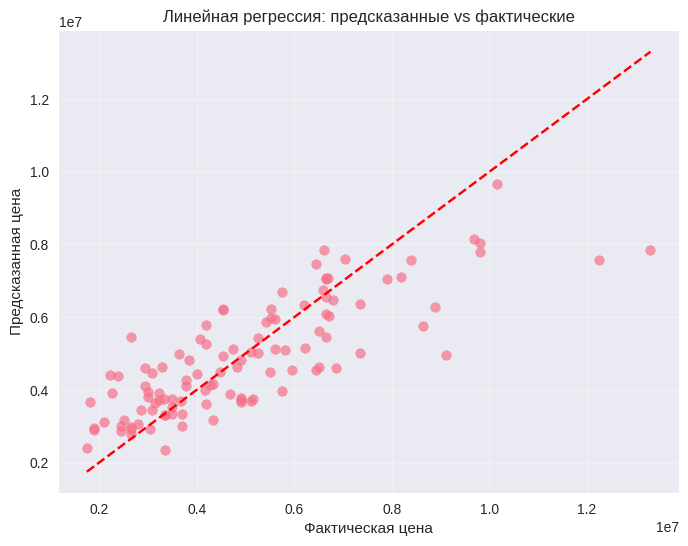

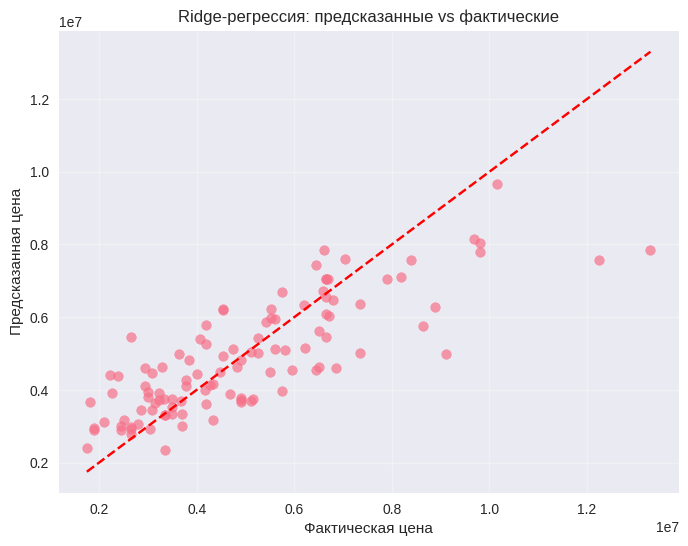

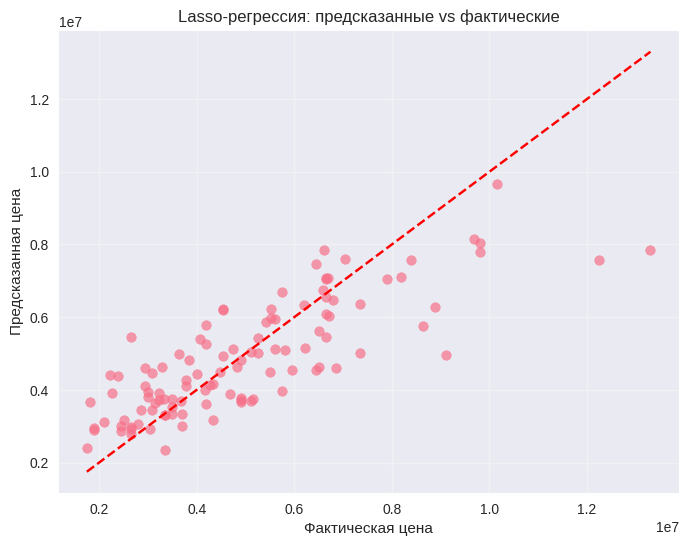

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

print('Линейная регрессия')
coefficients = pd.DataFrame({
    "Признак": X.columns,
    "Коэффициент": linear_model.coef_
})

print(coefficients)

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

print('Ridge регрессия')
coefficients = pd.DataFrame({
    "Признак": X.columns,
    "Коэффициент": ridge_model.coef_
})

print('\n', coefficients)

lasso_model = Lasso(alpha=1.0, max_iter=10000)
lasso_model.fit(X_train, y_train)

print('Lasso регрессия')
coefficients = pd.DataFrame({
    "Признак": X.columns,
    "Коэффициент": lasso_model.coef_
})

print('\n', coefficients)

y_pred_linear = linear_model.predict(X_test)
y_pred_ridge = ridge_model.predict(X_test)
y_pred_lasso = lasso_model.predict(X_test)

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_linear,
    alpha=0.7
)

min_price = min(y_test.min(), y_pred_linear.min())
max_price = max(y_test.max(), y_pred_linear.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    'r--'
)

plt.xlabel("Фактическая цена")
plt.ylabel("Предсказанная цена")
plt.title("Линейная регрессия: предсказанные vs фактические")

plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_ridge,
    alpha=0.7
)

min_price = min(y_test.min(), y_pred_ridge.min())
max_price = max(y_test.max(), y_pred_ridge.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    'r--'
)

plt.xlabel("Фактическая цена")
plt.ylabel("Предсказанная цена")
plt.title("Ridge-регрессия: предсказанные vs фактические")

plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_lasso,
    alpha=0.7
)

min_price = min(y_test.min(), y_pred_lasso.min())
max_price = max(y_test.max(), y_pred_lasso.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    'r--'
)

plt.xlabel("Фактическая цена")
plt.ylabel("Предсказанная цена")
plt.title("Lasso-регрессия: предсказанные vs фактические")

plt.grid(True, alpha=0.3)
plt.show()


# Вывод по регрессиям
При alpha=1 Ridge и особенно Lasso дают прогнозы, близкие к обычной линейной *регрессии. Для определения оптимальной силы регуляризации необходимо исследовать различные значения alpha с использованием кросс-валидации.*

In [12]:
def calculate_metrics(y_true, y_pred):

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    mape = mean_absolute_percentage_error(
        y_true,
        y_pred
    ) * 100

    return rmse, r2, mape

In [13]:

rmse_linear, r2_linear, mape_linear = calculate_metrics(
    y_test,
    y_pred_linear
)

rmse_ridge, r2_ridge, mape_ridge = calculate_metrics(
    y_test,
    y_pred_ridge
)

rmse_lasso, r2_lasso, mape_lasso = calculate_metrics(
    y_test,
    y_pred_lasso
)

results = pd.DataFrame({
    "Модель": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression"
    ],
    "RMSE": [
        rmse_linear,
        rmse_ridge,
        rmse_lasso
    ],
    "R²": [
        r2_linear,
        r2_ridge,
        r2_lasso
    ],
    "MAPE (%)": [
        mape_linear,
        mape_ridge,
        mape_lasso
    ]
})

print(results)

              Модель          RMSE        R²   MAPE (%)
0  Linear Regression  1.341937e+06  0.643730  21.702431
1   Ridge Regression  1.342129e+06  0.643628  21.705991
2   Lasso Regression  1.341937e+06  0.643729  21.702444


# Кросс-валидация

In [14]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

models = {
    "Linear Regression": linear_model,
    "Ridge Regression": ridge_model,
    "Lasso Regression": lasso_model
}

cv_results = []

for name, model in models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "RMSE": "neg_root_mean_squared_error",
            "R2": "r2",
            "MAPE": "neg_mean_absolute_percentage_error"
        },
        return_train_score=False
    )

    cv_results.append({
        "Модель": name,
        "CV RMSE": -scores["test_RMSE"].mean(),
        "CV R²": scores["test_R2"].mean(),
        "CV MAPE (%)": -scores["test_MAPE"].mean() * 100
    })

cv_results = pd.DataFrame(cv_results)

print("\nРезультаты 5-fold Cross-Validation:")
print(cv_results)


Результаты 5-fold Cross-Validation:
              Модель       CV RMSE     CV R²  CV MAPE (%)
0  Linear Regression  1.029802e+06  0.644896    16.878573
1   Ridge Regression  1.029696e+06  0.645019    16.875575
2   Lasso Regression  1.029802e+06  0.644896    16.878568


# Выводы после кросс-валидации
Для прогнозирования цены домов были построены три регрессионные модели: линейная регрессия, Ridge-регрессия и Lasso-регрессия. Данные были разделены на тренировочную и тестовую выборки в соотношении 80/20. Для оценки устойчивости моделей на тренировочной выборке применена 5-fold кросс-валидация.

На тестовой выборке линейная регрессия показала RMSE = 1,342·10⁶, \(R^2=0,644\), MAPE = 21,70%. Ridge и Lasso при \(alpha=1\) показали практически идентичные результаты. По результатам 5-fold кросс-валидации средний RMSE составил около 1,03·10⁶, \(R^2\) — около 0,645, MAPE — около 16,88%.

Существенного различия между тремя моделями при выбранном значении параметра регуляризации не наблюдается.

# Метод главных компонент

АНАЛИЗ ГЛАВНЫХ КОМПОНЕНТ

Объяснённая дисперсия по компонентам:
PC1: 0.216 (21.6%), cumulative = 0.216 (21.6%)
PC2: 0.145 (14.5%), cumulative = 0.361 (36.1%)
PC3: 0.114 (11.4%), cumulative = 0.474 (47.4%)
PC4: 0.100 (10.0%), cumulative = 0.574 (57.4%)
PC5: 0.082 (8.2%), cumulative = 0.656 (65.6%)
PC6: 0.074 (7.4%), cumulative = 0.731 (73.1%)
PC7: 0.066 (6.6%), cumulative = 0.797 (79.7%)
PC8: 0.062 (6.2%), cumulative = 0.858 (85.8%)
PC9: 0.055 (5.5%), cumulative = 0.913 (91.3%)
PC10: 0.051 (5.1%), cumulative = 0.964 (96.4%)
PC11: 0.036 (3.6%), cumulative = 1.000 (100.0%)

Собственные значения:
PC1: 2.3812
PC2: 1.5975
PC3: 1.2514
PC4: 1.1039
PC5: 0.9034
PC6: 0.8203
PC7: 0.7253
PC8: 0.6798
PC9: 0.6057
PC10: 0.5631
PC11: 0.3938

Оптимальное количество компонент:
- Для 85% дисперсии: 8
- Для 95% дисперсии: 10
- По правилу Кайзера (λ > 1): 4


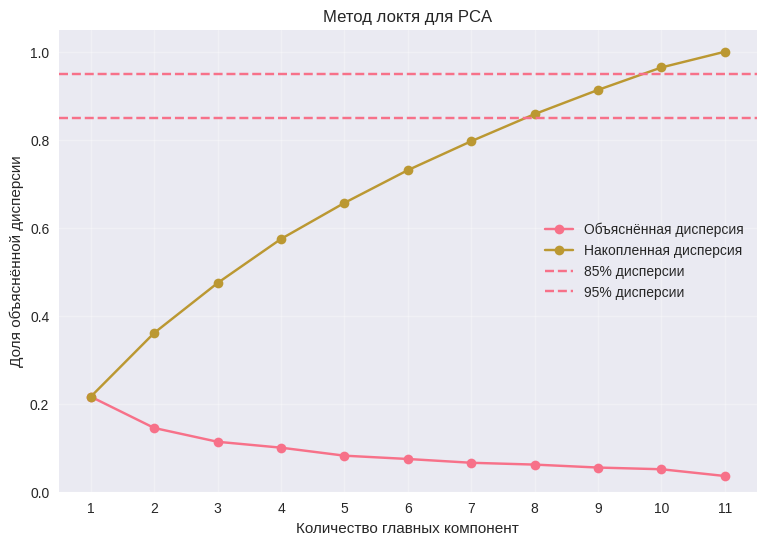

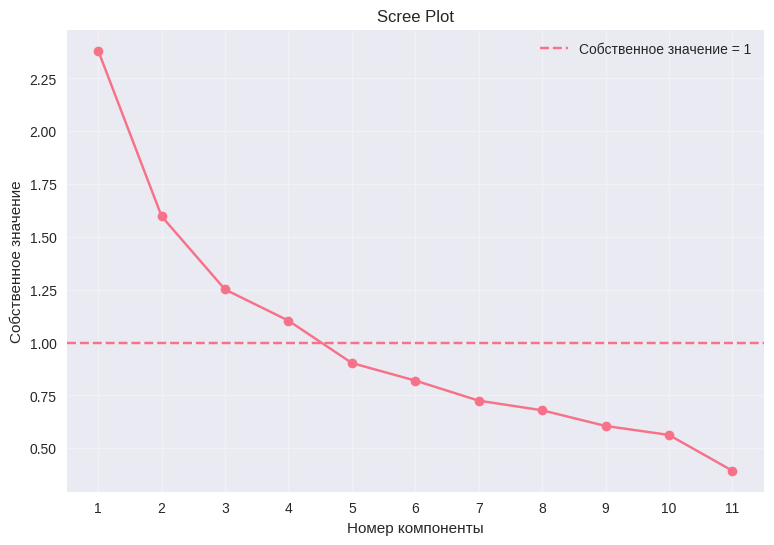

In [26]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler_pca = StandardScaler()

X_train_scaled = scaler_pca.fit_transform(X_train)
X_test_scaled = scaler_pca.transform(X_test)

pca_full = PCA()

X_train_pca_full = pca_full.fit_transform(
    X_train_scaled
)

eigenvalues = pca_full.explained_variance_

explained_ratio = pca_full.explained_variance_ratio_

cumulative = np.cumsum(explained_ratio)

print("=" * 60)
print("АНАЛИЗ ГЛАВНЫХ КОМПОНЕНТ")
print("=" * 60)

print("\nОбъяснённая дисперсия по компонентам:")

for i, value in enumerate(explained_ratio, 1):
    print(
        f"PC{i}: {value:.3f} "
        f"({value:.1%}), "
        f"cumulative = {cumulative[i-1]:.3f} "
        f"({cumulative[i-1]:.1%})"
    )

print("\nСобственные значения:")

for i, value in enumerate(eigenvalues, 1):
    print(f"PC{i}: {value:.4f}")

n_components_85 = np.argmax(
    cumulative >= 0.85
) + 1

n_components_95 = np.argmax(
    cumulative >= 0.95
) + 1


print("\nОптимальное количество компонент:")

print(
    f"- Для 85% дисперсии: {n_components_85}"
)

print(
    f"- Для 95% дисперсии: {n_components_95}"
)

n_components_kaiser = np.sum(
    eigenvalues > 1
)

print(
    f"- По правилу Кайзера (λ > 1): "
    f"{n_components_kaiser}"
)

plt.figure(figsize=(9, 6))

plt.plot(
    components,
    explained_ratio,
    marker='o',
    label='Объяснённая дисперсия'
)

plt.plot(
    components,
    cumulative,
    marker='o',
    label='Накопленная дисперсия'
)

plt.axhline(
    y=0.85,
    linestyle='--',
    label='85% дисперсии'
)

plt.axhline(
    y=0.95,
    linestyle='--',
    label='95% дисперсии'
)

plt.xlabel("Количество главных компонент")
plt.ylabel("Доля объяснённой дисперсии")
plt.title("Метод локтя для PCA")

plt.ylim(0, 1.05)
plt.xticks(components)

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

plt.figure(figsize=(9, 6))

components = np.arange(
    1,
    len(eigenvalues) + 1
)

plt.plot(
    components,
    eigenvalues,
    marker='o'
)

plt.axhline(
    y=1,
    linestyle='--',
    label='Собственное значение = 1'
)

plt.xlabel("Номер компоненты")
plt.ylabel("Собственное значение")
plt.title("Scree Plot")

plt.xticks(components)
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

# Выводы по PCA
По правилу Кайзера следует оставить 4 компоненты, однако они сохраняют только 57.4% общей дисперсии. Для дальнейшего регрессионного анализа выбраны 8 компонент, поскольку они позволяют сохранить 85.8% дисперсии при уменьшении размерности с 11 до 8 признаков.

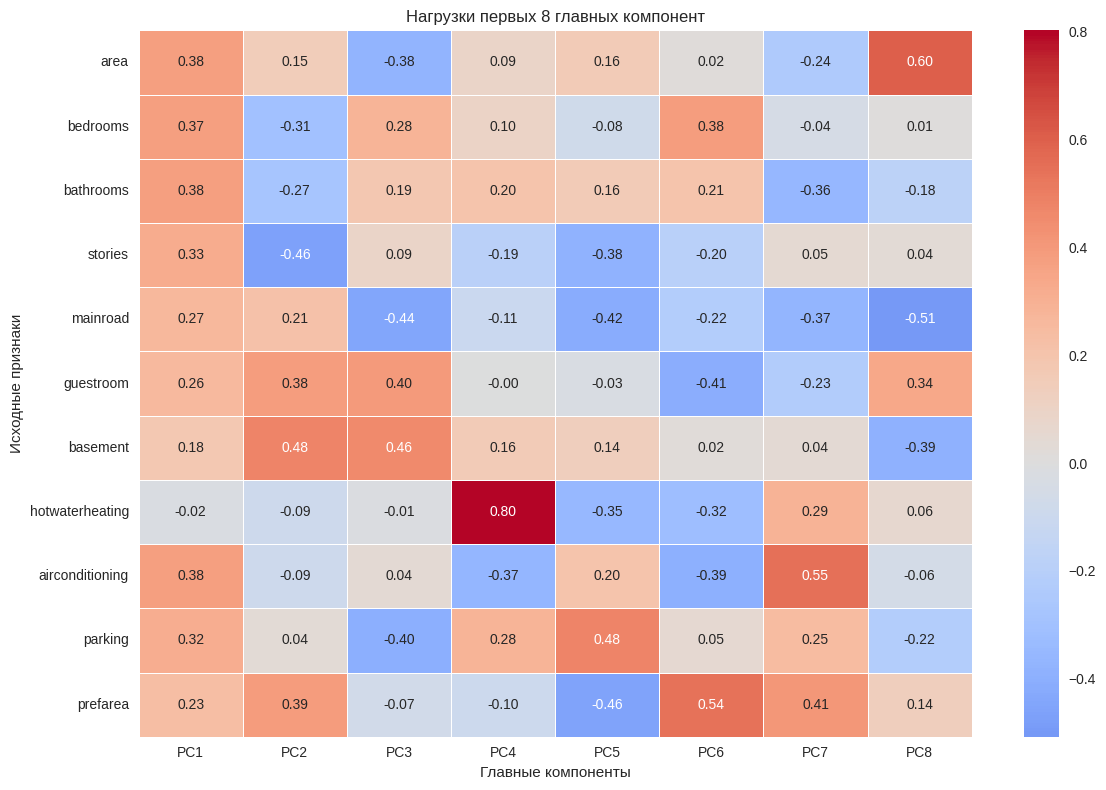


PC1:
area               0.380211
airconditioning    0.377594
bathrooms          0.377491
bedrooms           0.374359
Name: PC1, dtype: float64

PC2:
basement     0.480075
stories     -0.463833
prefarea     0.389984
guestroom    0.384330
Name: PC2, dtype: float64

PC3:
basement     0.461323
mainroad    -0.443182
parking     -0.402021
guestroom    0.396110
Name: PC3, dtype: float64

PC4:
hotwaterheating    0.802578
airconditioning   -0.367672
parking            0.283557
bathrooms          0.200484
Name: PC4, dtype: float64

PC5:
parking     0.480012
prefarea   -0.456299
mainroad   -0.416937
stories    -0.380481
Name: PC5, dtype: float64

PC6:
prefarea           0.537596
guestroom         -0.410008
airconditioning   -0.394959
bedrooms           0.384303
Name: PC6, dtype: float64

PC7:
airconditioning    0.551430
prefarea           0.412626
mainroad          -0.371232
bathrooms         -0.358346
Name: PC7, dtype: float64

PC8:
area         0.604692
mainroad    -0.507350
basement    -0.390

In [40]:
n_components = 8

pca = PCA(
    n_components=n_components
)

X_train_pca = pca.fit_transform(
    X_train_scaled
)

X_test_pca = pca.transform(
    X_test_scaled
)

loadings = pd.DataFrame(
    pca.components_.T,
    index=X.columns,
    columns=[f"PC{i}" for i in range(1, 9)]
)


plt.figure(figsize=(12, 8))

sns.heatmap(
    loadings,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Нагрузки первых 8 главных компонент")
plt.xlabel("Главные компоненты")
plt.ylabel("Исходные признаки")

plt.tight_layout()
plt.show()

for pc in loadings.columns:
    print(f"\n{pc}:")

    top_features = (
        loadings[pc]
        .sort_values(key=np.abs, ascending=False)
        .head(4)
    )

    print(top_features)


# Анализ нагрузок и интерпретация каждой компоненты:
### PC1 — общий размер и уровень оснащения жилья
### PC2 — Дополнительное пространство и характеристики объекта
### PC3 — Дополнительные удобства и инфраструктура
### PC4 — горячее водоснабжение и климатическое оснащение
### PC5 — Парковка и расположение
### PC6 — предпочтительность расположения и дополнительные характеристики жилья
### PC7 — кондиционирование и характеристики расположения
### PC8 — площадь и инфраструктурные характеристики

In [ ]:
linear_pca_model = LinearRegression()

linear_pca_model.fit(
    X_train_pca,
    y_train
)

y_pred_linear_pca = linear_pca_model.predict(
    X_test_pca
)

ridge_pca_model = Ridge(
    alpha=1.0
)

ridge_pca_model.fit(
    X_train_pca,
    y_train
)

y_pred_ridge_pca = ridge_pca_model.predict(
    X_test_pca
)

lasso_pca_model = Lasso(
    alpha=1.0,
    max_iter=10000
)

lasso_pca_model.fit(
    X_train_pca,
    y_train
)

y_pred_lasso_pca = lasso_pca_model.predict(
    X_test_pca
)

rmse_linear_pca, r2_linear_pca, mape_linear_pca = calculate_metrics(
    y_test,
    y_pred_linear_pca
)

rmse_ridge_pca, r2_ridge_pca, mape_ridge_pca = calculate_metrics(
    y_test,
    y_pred_ridge_pca
)

rmse_lasso_pca, r2_lasso_pca, mape_lasso_pca = calculate_metrics(
    y_test,
    y_pred_lasso_pca
)

pca_results = pd.DataFrame({

    "Модель": [
        "Linear Regression PCA",
        "Ridge Regression PCA",
        "Lasso Regression PCA"
    ],

    "RMSE": [
        rmse_linear_pca,
        rmse_ridge_pca,
        rmse_lasso_pca
    ],

    "R²": [
        r2_linear_pca,
        r2_ridge_pca,
        r2_lasso_pca
    ],

    "MAPE (%)": [
        mape_linear_pca,
        mape_ridge_pca,
        mape_lasso_pca
    ]
})


comparison_pca = pd.concat(
    [
        results.assign(
            Данные="Исходные признаки"
        ),
        pca_results.assign(
            Данные="PCA (8 компонент)"
        )
    ],
    ignore_index=True
)

print(comparison_pca)

In [36]:
def plot_predictions(ax, y_true, y_pred, title):
    ax.scatter(
        y_true,
        y_pred,
        alpha=0.7
    )

    min_price = min(
        y_true.min(),
        y_pred.min()
    )

    max_price = max(
        y_true.max(),
        y_pred.max()
    )

    ax.plot(
        [min_price, max_price],
        [min_price, max_price],
        'r--',
        label='Идеальное предсказание'
    )

    ax.set_xlabel("Фактическая цена")
    ax.set_ylabel("Предсказанная цена")
    ax.set_title(title)

    ax.grid(True, alpha=0.3)
    ax.legend()

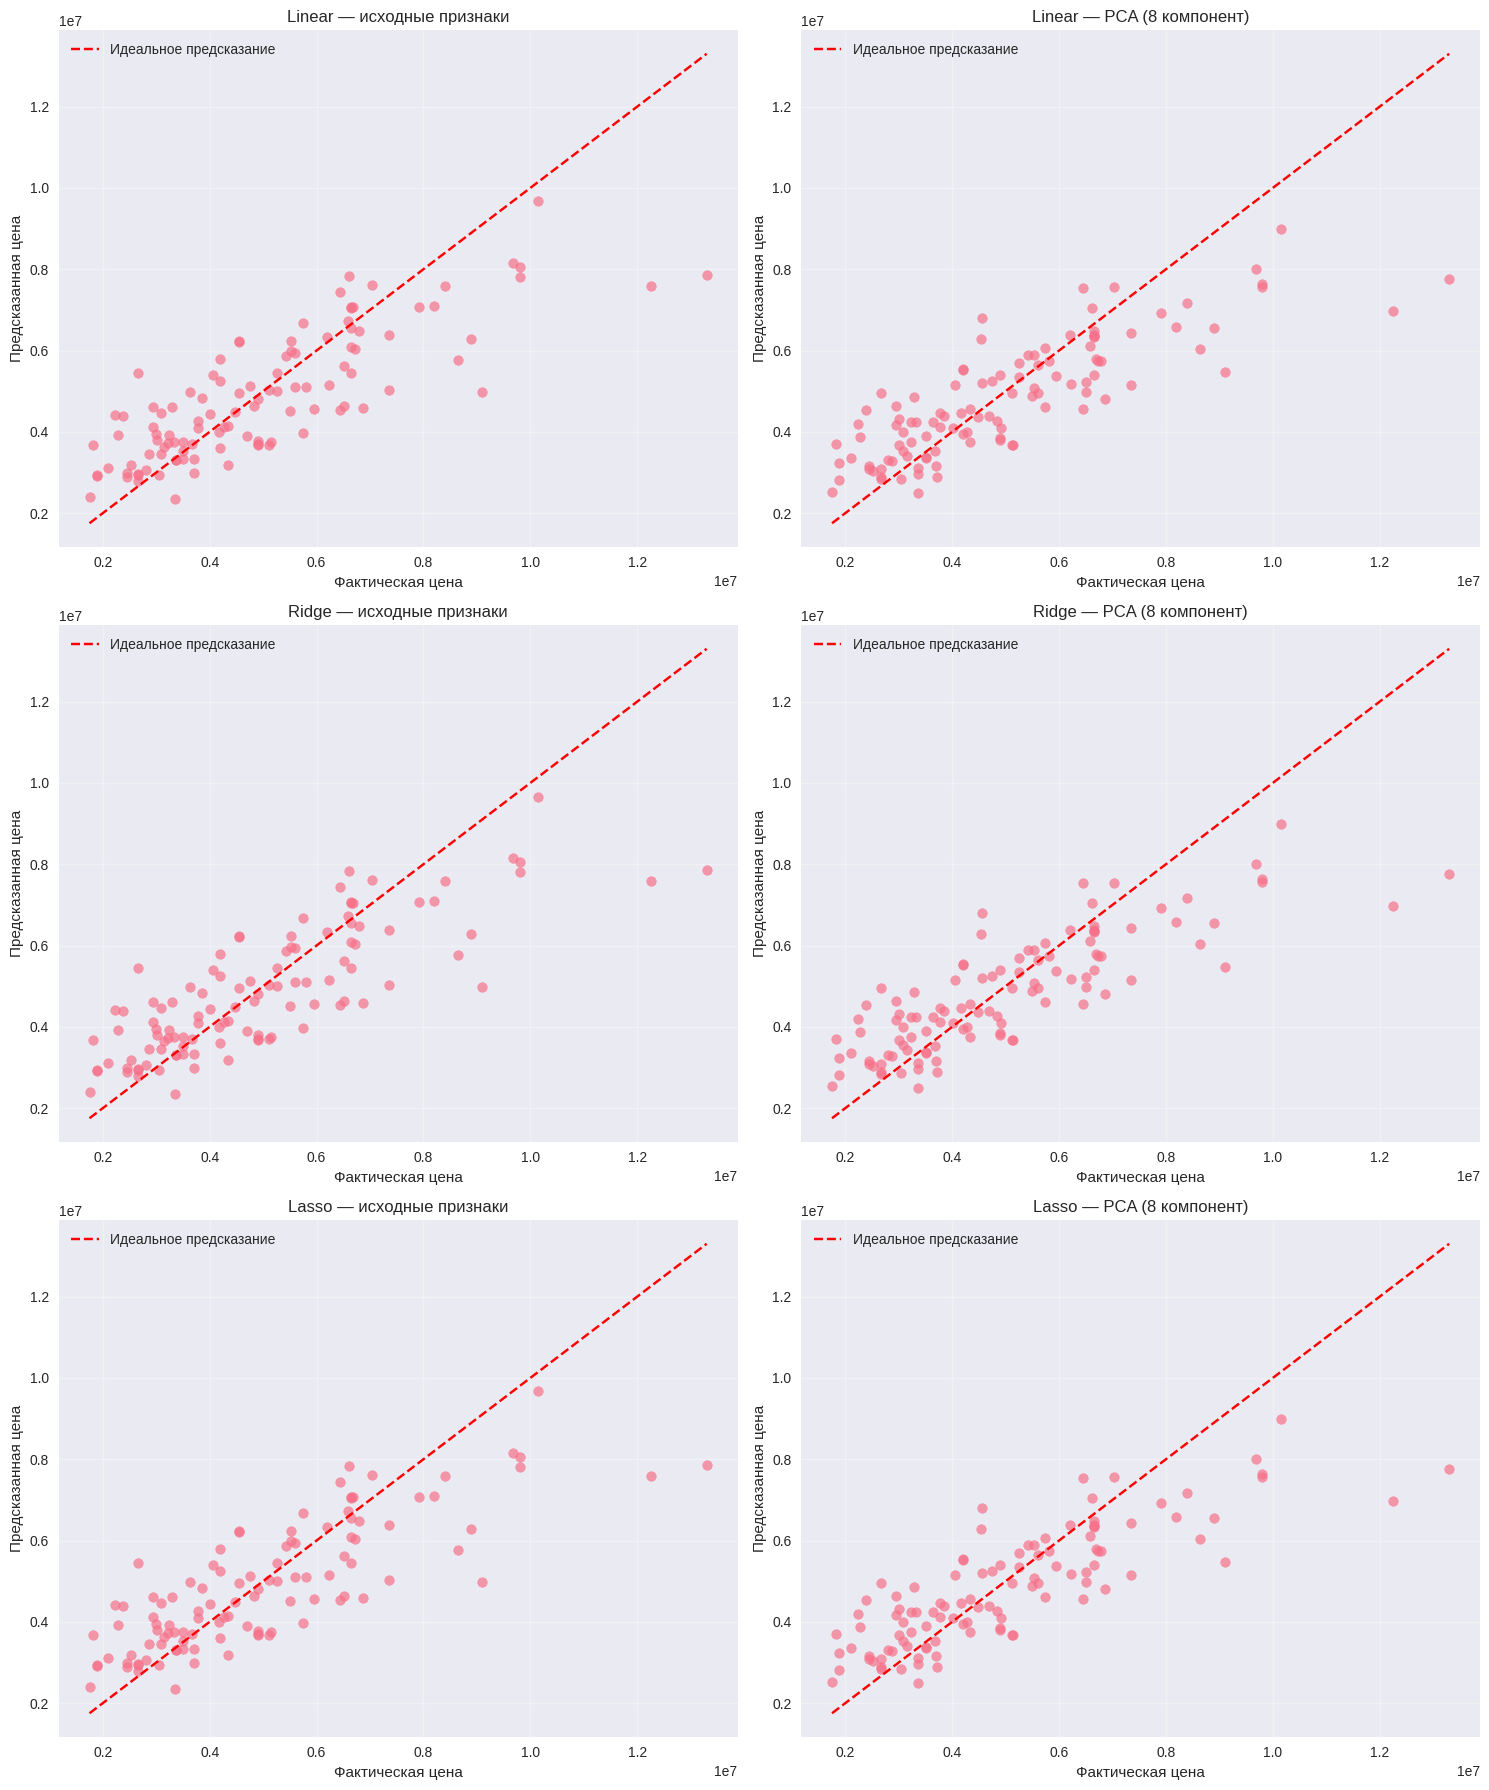

In [37]:
fig, axes = plt.subplots(
    3, 2,
    figsize=(15, 18)
)

plot_predictions(
    axes[0, 0],
    y_test,
    y_pred_linear,
    "Linear — исходные признаки"
)

plot_predictions(
    axes[0, 1],
    y_test,
    y_pred_linear_pca,
    "Linear — PCA (8 компонент)"
)


plot_predictions(
    axes[1, 0],
    y_test,
    y_pred_ridge,
    "Ridge — исходные признаки"
)

plot_predictions(
    axes[1, 1],
    y_test,
    y_pred_ridge_pca,
    "Ridge — PCA (8 компонент)"
)


plot_predictions(
    axes[2, 0],
    y_test,
    y_pred_lasso,
    "Lasso — исходные признаки"
)

plot_predictions(
    axes[2, 1],
    y_test,
    y_pred_lasso_pca,
    "Lasso — PCA (8 компонент)"
)

plt.tight_layout()
plt.show()

# Заключение
В результате исследования было установлено, что применение PCA не привело к существенному изменению качества регрессионных моделей. При сокращении размерности с 11 исходных признаков до 8 главных компонент удалось сохранить 85,8% общей дисперсии признакового пространства. Для линейной регрессии RMSE уменьшился с \(1,342 * 10^6\) до \(1,339 * 10^6\), а \(R^2\) увеличился с 0,644 до 0,645. В то же время MAPE немного увеличился с 21,70% до 21,83%. Таким образом, PCA оправдал себя как метод снижения размерности и устранения мультиколлинеарности, однако существенного улучшения прогнозного качества не дал. Модели на исходных признаках и на главных компонентах показали практически одинаковые результаты, поэтому выбор PCA в данном случае определяется преимуществом более компактного и некоррелированного признакового пространства, а не повышением точности прогнозирования.